In [1]:
import pandas as pd
import matplotlib.pyplot as plt

orders = pd.read_csv("../data/olist_orders_dataset.csv")
items = pd.read_csv("../data/olist_order_items_dataset.csv")
payments = pd.read_csv("../data/olist_order_payments_dataset.csv")
customers = pd.read_csv("../data/olist_customers_dataset.csv")

In [2]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [3]:
df = orders.merge(customers, on="customer_id")
df = df.merge(payments, on="order_id")
df = df.merge(items, on="order_id")

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 117601 entries, 0 to 117600
Data columns (total 22 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       117601 non-null  str    
 1   customer_id                    117601 non-null  str    
 2   order_status                   117601 non-null  str    
 3   order_purchase_timestamp       117601 non-null  str    
 4   order_approved_at              117586 non-null  str    
 5   order_delivered_carrier_date   116356 non-null  str    
 6   order_delivered_customer_date  115034 non-null  str    
 7   order_estimated_delivery_date  117601 non-null  str    
 8   customer_unique_id             117601 non-null  str    
 9   customer_zip_code_prefix       117601 non-null  int64  
 10  customer_city                  117601 non-null  str    
 11  customer_state                 117601 non-null  str    
 12  payment_sequential             117601 non

In [5]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

In [6]:
df.to_csv("../Notebook/Cleaned_Marketing_Data.csv", index=False)

In [7]:
print("Total Orders:", df["order_id"].nunique())
print("Total Customers:", df["customer_id"].nunique())
print("Total Revenue:", df["payment_value"].sum())

Total Orders: 96460
Total Customers: 96460
Total Revenue: 19773394.700000003


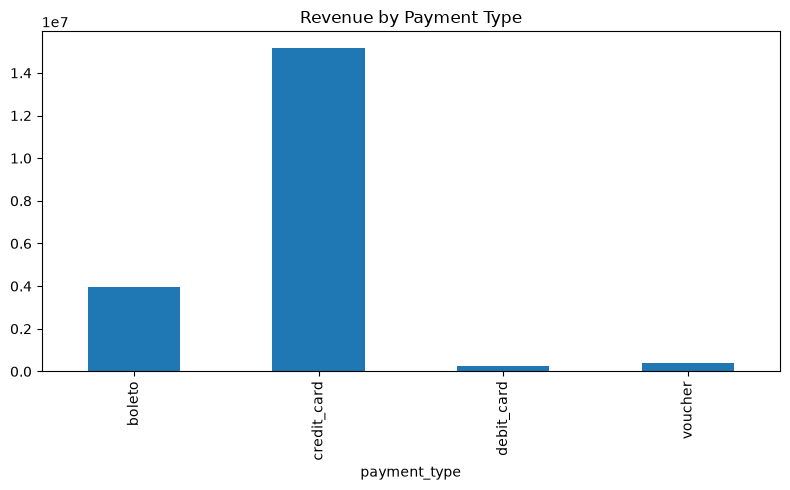

In [8]:
plt.figure(figsize=(8,5))

df.groupby("payment_type")["payment_value"].sum().plot(kind="bar")

plt.title("Revenue by Payment Type")
plt.tight_layout()

plt.savefig("../Images/revenue_by_payment_type.png")

plt.show()

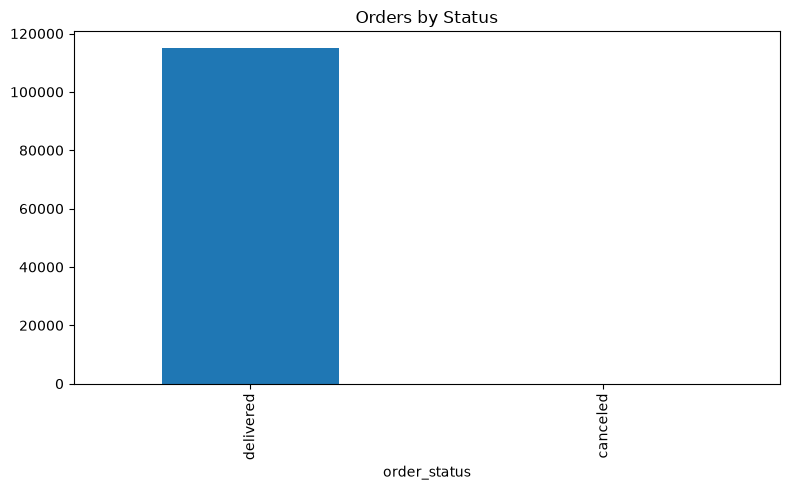

In [9]:
plt.figure(figsize=(8,5))

df["order_status"].value_counts().plot(kind="bar")

plt.title("Orders by Status")
plt.tight_layout()

plt.savefig("../Images/orders_by_status.png")

plt.show()

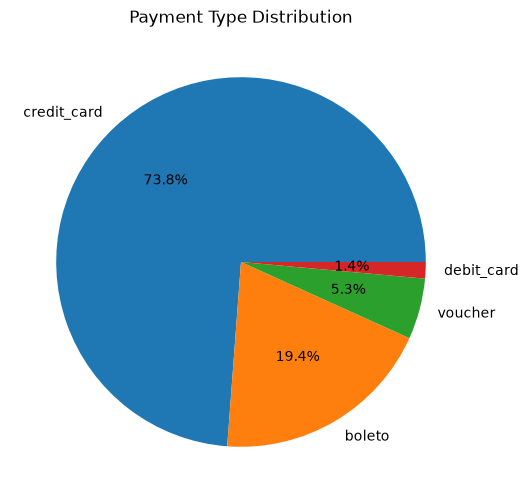

In [10]:
plt.figure(figsize=(6,6))

df["payment_type"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")

plt.title("Payment Type Distribution")

plt.savefig("../Images/payment_distribution.png")

plt.show()